# EEG-Based Major Depressive Disorder (MDD) Classification
## PSD Feature Extraction · RF · GB · KNN · LSTM · LRCN

### Methodology Pipeline
```
EDF Files (MDD / Healthy)
        ↓
  1. Noise Filtering & Band Extraction
        ↓
  2. Labeling  (Normal=1 / MDD=0)
        ↓
  3. Z-Score Normalisation (row-wise)
        ↓
  4. Mean Imputation (missing values)
        ↓
  5. SMOTE  (class-imbalance correction)
        ↓
  6. 80/20 Train–Test Split
        ↓
  PSD Feature Extraction
  (delta · theta · alpha · beta · gamma · spectral entropy)
        ↓
  Train & Evaluate 5 Classifiers
  RF | Gradient Boosting | KNN | LSTM | LRCN
```

## 0. Install Dependencies

In [1]:
!pip install mne numpy pandas scikit-learn imbalanced-learn scipy torch torchvision \
             matplotlib seaborn tqdm -q

## 1. Imports & Global Configuration

In [2]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from scipy import signal, stats

import mne
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# ── SMOTE ─────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print('All imports successful.')

Device : cpu
All imports successful.


## 2. Channel Configuration & Hyperparameters

In [5]:
# ── Fixed channel sets ────────────────────────────────────────────────────────
CHANNELS_19 = [
    'EEG Fp1-LE', 'EEG F3-LE',  'EEG C3-LE',  'EEG P3-LE',
    'EEG O1-LE',  'EEG F7-LE',  'EEG T3-LE',  'EEG T5-LE',
    'EEG Fz-LE',  'EEG Fp2-LE', 'EEG F4-LE',  'EEG C4-LE',
    'EEG P4-LE',  'EEG O2-LE',  'EEG F8-LE',  'EEG T4-LE',
    'EEG T6-LE',  'EEG Cz-LE',  'EEG Pz-LE'
]
CHANNELS_4  = ['EEG Fp1-LE', 'EEG Fp2-LE', 'EEG F3-LE', 'EEG F4-LE']

# ── Active channel set (change here to switch) ────────────────────────────────
SELECTED_CHANNELS = CHANNELS_19

# ── Frequency band definitions (Hz) ──────────────────────────────────────────
BANDS = {
    'delta' : (0.5,  4.0),
    'theta' : (4.0,  8.0),
    'alpha' : (8.0,  12.0),
    'beta'  : (13.0, 30.0),
    'gamma' : (30.0, 45.0),
}

# ── Preprocessing ─────────────────────────────────────────────────────────────
SFREQ_TARGET  = 256          # resample to 256 Hz
NOTCH_FREQ    = 50.0         # power-line noise
BP_LOW        = 0.5          # bandpass low-cut
BP_HIGH       = 45.0         # bandpass high-cut

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_SEC    = 4            # epoch length (s)
OVERLAP       = 0.5          # 50 % overlap

# ── Data directory ────────────────────────────────────────────────────────────
DATA_DIR      = 'EEG Data'      # folder containing all .edf files

print(f'Channels selected : {len(SELECTED_CHANNELS)}')
print(f'Frequency bands   : {list(BANDS.keys())} + spectral_entropy')

Channels selected : 19
Frequency bands   : ['delta', 'theta', 'alpha', 'beta', 'gamma'] + spectral_entropy


## 3. Data Loading — EDF Files

In [6]:
def load_edf_paths(data_dir: str):
    """
    Scan data_dir for EDF files.
    MDD*.edf  → label 0  (patient / MDD)
    H*.edf    → label 1  (healthy / normal)
    Returns: (file_paths, labels)
    """
    all_edfs = sorted(glob.glob(os.path.join(data_dir, '*.edf')))
    paths, labels = [], []
    for fp in all_edfs:
        name = os.path.basename(fp)
        if name.startswith('MDD'):
            paths.append(fp);  labels.append(0)   # MDD = 0
        elif name.startswith('H'):
            paths.append(fp);  labels.append(1)   # Normal = 1
        else:
            print(f'  [SKIP] {name}')
    print(f'Found {len(paths)} EDF files')
    print(f'  MDD (0)     : {labels.count(0)}')
    print(f'  Healthy (1) : {labels.count(1)}')
    return paths, labels


edf_paths, edf_labels = load_edf_paths(DATA_DIR)

  [SKIP] 6921143_H S15 EO.edf
  [SKIP] 6921959_H S15 EO.edf
Found 179 EDF files
  MDD (0)     : 95
  Healthy (1) : 84


## 4. Preprocessing — Step 1: Noise Filtering & Band Extraction

In [7]:
def preprocess_raw(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    """
    Step 1 of the 6-step pipeline:
      - Select channels
      - Resample to SFREQ_TARGET
      - Notch filter (50 Hz power-line noise)
      - Bandpass filter (0.5–45 Hz)
    """
    # Select available channels
    available = [ch for ch in SELECTED_CHANNELS if ch in raw.ch_names]
    missing   = set(SELECTED_CHANNELS) - set(available)
    if missing:
        print(f'    [WARN] missing: {missing}')
    raw.pick_channels(available)

    # Resample
    if raw.info['sfreq'] != SFREQ_TARGET:
        raw.resample(SFREQ_TARGET)

    # Notch
    raw.notch_filter(NOTCH_FREQ, fir_window='hamming')

    # Bandpass
    raw.filter(l_freq=BP_LOW, h_freq=BP_HIGH,
               fir_window='hamming', picks='eeg')
    return raw


def make_windows(data: np.ndarray, sfreq: float) -> np.ndarray:
    """Slice (n_ch, n_samples) into overlapping windows → (N, n_ch, win_samples)."""
    win  = int(WINDOW_SEC * sfreq)
    step = int(win * (1 - OVERLAP))
    idx  = range(0, data.shape[1] - win + 1, step)
    return np.array([data[:, i:i+win] for i in idx])


print('Preprocessing helpers defined.')

Preprocessing helpers defined.


## 5. Feature Extraction — PSD + Spectral Entropy

In [8]:
def band_power(freqs: np.ndarray, psd: np.ndarray,
               low: float, high: float) -> float:
    """Integrate PSD within [low, high] Hz using the trapezoidal rule."""
    idx = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(psd[idx], freqs[idx])


def spectral_entropy(freqs: np.ndarray, psd: np.ndarray) -> float:
    """
    Spectral entropy — measures signal irregularity / complexity.
    Normalised PSD is treated as a probability distribution; Shannon
    entropy is computed and normalised by log(N).
    """
    psd_norm = psd / (np.sum(psd) + 1e-12)
    se       = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return se / np.log2(len(psd_norm) + 1e-12)   # normalise to [0, 1]


def extract_psd_features(window: np.ndarray, sfreq: float) -> np.ndarray:
    """
    Given a window of shape (n_channels, n_samples), compute:
      delta, theta, alpha, beta, gamma band power + spectral entropy
    for each channel.  Returns a 1-D feature vector of length
      n_channels × 6 features.
    """
    features = []
    for ch_signal in window:                         # iterate over channels
        freqs, psd = signal.welch(
            ch_signal, fs=sfreq,
            nperseg=min(256, len(ch_signal))
        )
        ch_feats = [
            band_power(freqs, psd, *BANDS['delta']),
            band_power(freqs, psd, *BANDS['theta']),
            band_power(freqs, psd, *BANDS['alpha']),
            band_power(freqs, psd, *BANDS['beta']),
            band_power(freqs, psd, *BANDS['gamma']),
            spectral_entropy(freqs, psd),
        ]
        features.extend(ch_feats)
    return np.array(features, dtype=np.float32)


# Build feature-name list for interpretability
FEATURE_NAMES = [
    f'{ch.split()[1]}_{band}'
    for ch in SELECTED_CHANNELS
    for band in list(BANDS.keys()) + ['spec_entropy']
]

print(f'Features per window : {len(SELECTED_CHANNELS)} channels × 6 = {len(SELECTED_CHANNELS)*6}')

Features per window : 19 channels × 6 = 114


## 6. Build Raw Feature Matrix from All EDF Files

In [9]:
X_raw_list, y_raw_list = [], []

for fp, lbl in tqdm(zip(edf_paths, edf_labels),
                    total=len(edf_paths), desc='Processing EDF'):
    try:
        raw  = mne.io.read_raw_edf(fp, preload=True, verbose=False)
        raw  = preprocess_raw(raw)
        data = raw.get_data() * 1e6    # V → µV, shape (n_ch, n_samples)
        sfreq = raw.info['sfreq']

        windows = make_windows(data, sfreq)    # (N, C, T)

        for win in windows:
            feat = extract_psd_features(win, sfreq)
            X_raw_list.append(feat)
            y_raw_list.append(lbl)

    except Exception as e:
        print(f'  [ERROR] {os.path.basename(fp)}: {e}')


X_raw = np.array(X_raw_list, dtype=np.float32)
y_raw = np.array(y_raw_list, dtype=np.int64)

print(f'\nRaw feature matrix : X={X_raw.shape}   y={y_raw.shape}')
print(f'Class counts       : MDD(0)={np.sum(y_raw==0)}  Healthy(1)={np.sum(y_raw==1)}')

Processing EDF: 100%|██████████| 179/179 [20:42<00:00,  6.94s/it]


Raw feature matrix : X=(36473, 114)   y=(36473,)
Class counts       : MDD(0)=19520  Healthy(1)=16953


## 7. Preprocessing Steps 2–5: Label, Z-Score, Impute, SMOTE

In [10]:
# ── Step 2: Labels already assigned (MDD=0, Normal=1) ─────────────────────────
print('Step 2 — Labels: MDD=0, Healthy/Normal=1 ✓')

# ── Step 3: Z-Score Normalisation (row-wise per sample) ───────────────────────
# Each window/sample is normalised independently across its features
X_mean = X_raw.mean(axis=1, keepdims=True)
X_std  = X_raw.std(axis=1, keepdims=True) + 1e-12
X_norm = (X_raw - X_mean) / X_std
print(f'Step 3 — Z-Score normalisation applied (row-wise)  ✓')
print(f'         Sample mean range: [{X_norm.mean(axis=1).min():.4f}, {X_norm.mean(axis=1).max():.4f}]')

# ── Step 4: Mean Imputation (handles NaN / Inf) ────────────────────────────────
X_norm = np.where(np.isinf(X_norm), np.nan, X_norm)   # inf → NaN first
imputer = SimpleImputer(strategy='mean')
X_imp   = imputer.fit_transform(X_norm)
nan_count = np.isnan(X_norm).sum()
print(f'Step 4 — Mean imputation: {nan_count} NaN values replaced  ✓')

# ── Step 5: SMOTE — Synthetic Minority Over-sampling ──────────────────────────
print(f'Step 5 — Before SMOTE: MDD(0)={np.sum(y_raw==0)}  Healthy(1)={np.sum(y_raw==1)}')
smote    = SMOTE(random_state=SEED)
X_bal, y_bal = smote.fit_resample(X_imp, y_raw)
print(f'         After  SMOTE: MDD(0)={np.sum(y_bal==0)}  Healthy(1)={np.sum(y_bal==1)}  ✓')

# ── Step 6: 80 / 20 Stratified Train–Test Split ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = y_bal
)
print(f'Step 6 — 80/20 split: Train={len(y_train)}  Test={len(y_test)}  ✓')

Step 2 — Labels: MDD=0, Healthy/Normal=1 ✓
Step 3 — Z-Score normalisation applied (row-wise)  ✓
         Sample mean range: [-0.0000, 0.0000]
Step 4 — Mean imputation: 0 NaN values replaced  ✓
Step 5 — Before SMOTE: MDD(0)=19520  Healthy(1)=16953
         After  SMOTE: MDD(0)=19520  Healthy(1)=19520  ✓
Step 6 — 80/20 split: Train=31232  Test=7808  ✓


## 8. EDA — Feature Distribution & Band Power Visualisation

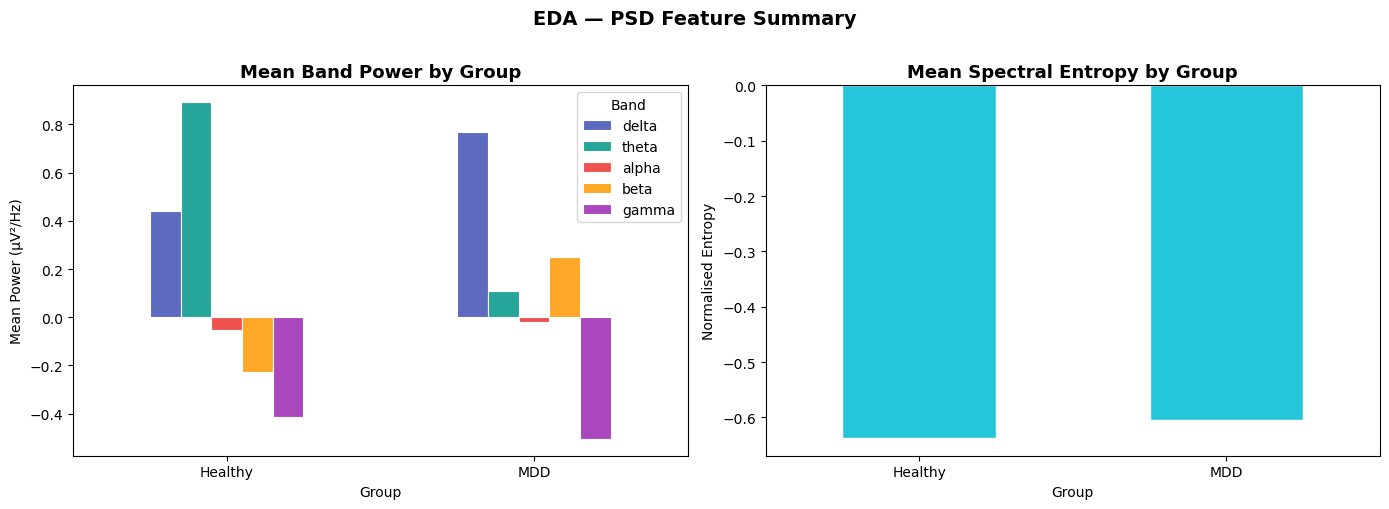

In [11]:
# Build a DataFrame for visualisation
feat_df      = pd.DataFrame(X_bal, columns=FEATURE_NAMES)
feat_df['label'] = y_bal
feat_df['group'] = feat_df['label'].map({0: 'MDD', 1: 'Healthy'})

# ── Mean band power per group (averaged over channels) ────────────────────────
band_cols = {b: [c for c in FEATURE_NAMES if c.endswith(f'_{b}')] for b in BANDS}
se_cols   = [c for c in FEATURE_NAMES if c.endswith('_spec_entropy')]

summary = {}
for grp, grp_df in feat_df.groupby('group'):
    row = {b: grp_df[cols].values.mean() for b, cols in band_cols.items()}
    row['spec_entropy'] = grp_df[se_cols].values.mean()
    summary[grp] = row

summary_df = pd.DataFrame(summary).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — mean band power
summary_df[list(BANDS.keys())].plot(
    kind='bar', ax=axes[0], color=['#5C6BC0','#26A69A','#EF5350','#FFA726','#AB47BC'],
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Mean Band Power by Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Group');  axes[0].set_ylabel('Mean Power (µV²/Hz)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Band')

# Bar chart — spectral entropy
summary_df[['spec_entropy']].plot(
    kind='bar', ax=axes[1], color=['#26C6DA','#FF7043'],
    edgecolor='white', legend=False
)
axes[1].set_title('Mean Spectral Entropy by Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Group');  axes[1].set_ylabel('Normalised Entropy')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('EDA — PSD Feature Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_band_power.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Statistical significance test — gamma band (p < 0.05) ─────────────────────
print('Mann-Whitney U test on gamma band power (MDD vs Healthy):')
for ch in SELECTED_CHANNELS[:6]:   # show first 6 channels
    col = f'{ch.split()[1]}_gamma'
    if col not in feat_df.columns:
        continue
    mdd_vals     = feat_df.loc[feat_df['label']==0, col].values
    healthy_vals = feat_df.loc[feat_df['label']==1, col].values
    stat, p      = stats.mannwhitneyu(mdd_vals, healthy_vals, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {col:<25}  U={stat:.0f}  p={p:.4e}  {sig}')

Mann-Whitney U test on gamma band power (MDD vs Healthy):
  Fp1-LE_gamma               U=179047666  p=7.0755e-25  ***
  F3-LE_gamma                U=199474074  p=8.5238e-16  ***
  C3-LE_gamma                U=168914296  p=7.5807e-84  ***
  P3-LE_gamma                U=170896164  p=1.7029e-69  ***
  O1-LE_gamma                U=150920090  p=5.3315e-277  ***
  F7-LE_gamma                U=190187848  p=7.6875e-01  ns


## 9. Utility — Metrics Reporter

In [13]:
results_log = {}

def evaluate(name: str, y_true, y_pred, y_prob=None, plot_cm=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    spec = recall_score(y_true, y_pred, pos_label=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')

    results_log[name] = dict(
        Accuracy=acc, Precision=prec, Recall_Sensitivity=rec,
        Specificity=spec, F1=f1, ROC_AUC=auc
    )

    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'{"="*52}')
    print(f'  Accuracy          : {acc*100:.2f} %')
    print(f'  Precision         : {prec*100:.2f} %')
    print(f'  Recall/Sensitivity: {rec*100:.2f} %')
    print(f'  Specificity       : {spec*100:.2f} %')
    print(f'  F1-Score          : {f1*100:.2f} %')
    print(f'  ROC-AUC           : {auc:.4f}')

    if plot_cm:
        cm   = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['MDD', 'Healthy'])
        fig, ax = plt.subplots(figsize=(4, 4))
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
        plt.tight_layout(); plt.show()


print('Evaluation utility ready.')

Evaluation utility ready.


## 10. Model 1 — Random Forest

Training Random Forest …
  OOB Accuracy : 98.12 %

  Random Forest
  Accuracy          : 98.49 %
  Precision         : 99.63 %
  Recall/Sensitivity: 97.34 %
  Specificity       : 99.64 %
  F1-Score          : 98.47 %
  ROC-AUC           : 0.9987


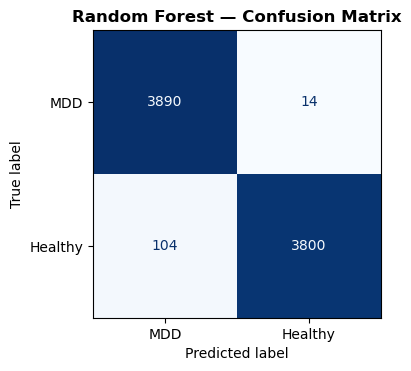

In [14]:
rf = RandomForestClassifier(
    n_estimators    = 500,
    max_depth       = None,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    max_features    = 'sqrt',
    class_weight    = 'balanced',
    oob_score       = True,
    random_state    = SEED,
    n_jobs          = -1
)
print('Training Random Forest …')
rf.fit(X_train, y_train)
print(f'  OOB Accuracy : {rf.oob_score_*100:.2f} %')

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
evaluate('Random Forest', y_test, rf_pred, rf_prob)

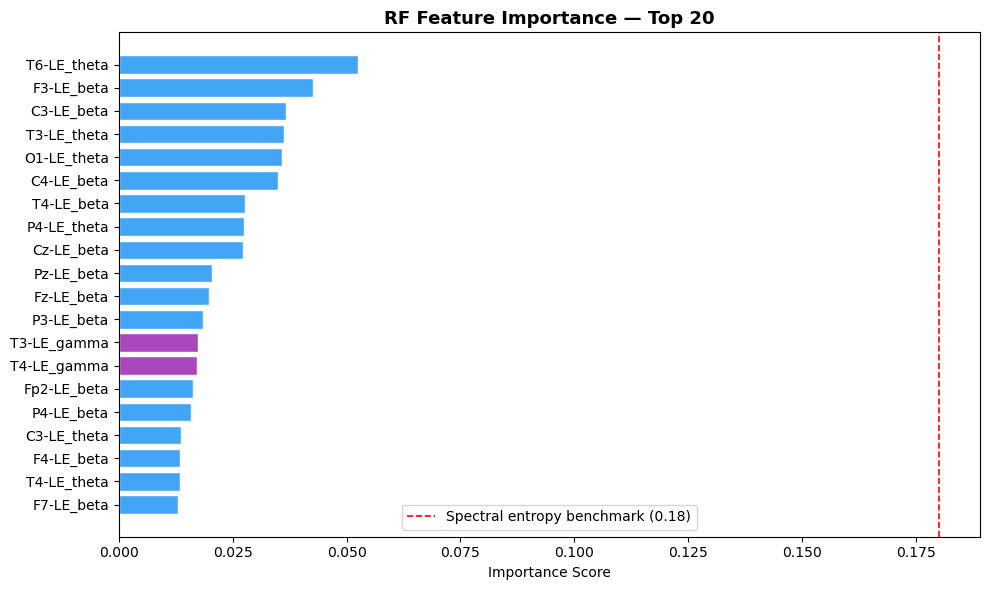

In [15]:
# ── Feature importance (RF) ───────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#E53935' if 'spec_entropy' in f else
           '#AB47BC' if 'gamma' in f else '#42A5F5'
           for f in importance_df['feature']]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('RF Feature Importance — Top 20', fontsize=13, fontweight='bold')
ax.axvline(0.18, color='red', linestyle='--', linewidth=1.2,
           label='Spectral entropy benchmark (0.18)')
ax.legend()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Model 2 — Gradient Boosting

Training Gradient Boosting …

  Gradient Boosting
  Accuracy          : 98.30 %
  Precision         : 98.96 %
  Recall/Sensitivity: 97.62 %
  Specificity       : 98.98 %
  F1-Score          : 98.28 %
  ROC-AUC           : 0.9983


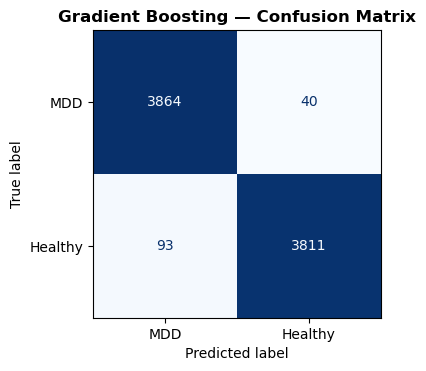

In [16]:
gb = GradientBoostingClassifier(
    n_estimators  = 300,
    max_depth     = 5,
    learning_rate = 0.05,
    subsample     = 0.8,
    min_samples_split = 4,
    min_samples_leaf  = 2,
    random_state  = SEED
)
print('Training Gradient Boosting …')
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
evaluate('Gradient Boosting', y_test, gb_pred, gb_prob)

## 12. Model 3 — K-Nearest Neighbours (k=5)

Training KNN (k=5) …

  KNN (k=5)
  Accuracy          : 98.31 %
  Precision         : 98.66 %
  Recall/Sensitivity: 97.95 %
  Specificity       : 98.67 %
  F1-Score          : 98.30 %
  ROC-AUC           : 0.9979


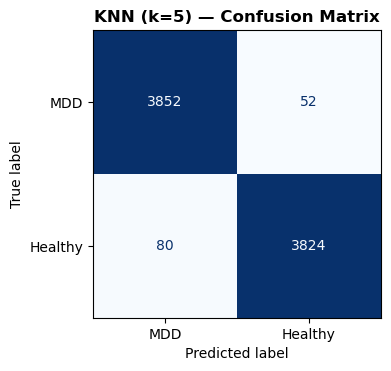

In [17]:
# Scale features for distance-based KNN
knn_scaler  = StandardScaler()
X_tr_knn    = knn_scaler.fit_transform(X_train)
X_te_knn    = knn_scaler.transform(X_test)

knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights     = 'distance',
    metric      = 'euclidean',
    n_jobs      = -1
)
print('Training KNN (k=5) …')
knn.fit(X_tr_knn, y_train)

knn_pred = knn.predict(X_te_knn)
knn_prob = knn.predict_proba(X_te_knn)[:, 1]
evaluate('KNN (k=5)', y_test, knn_pred, knn_prob)

## 13. Deep Learning — Shared Helpers

In [18]:
# ── Reshape features into sequences for LSTM / LRCN ──────────────────────────
# Treat each channel's 6 PSD features as one time-step
# → sequence length = n_channels, features per step = 6
N_FEATS_PER_CH = 6   # delta, theta, alpha, beta, gamma, spec_entropy
N_CH           = len(SELECTED_CHANNELS)

def to_sequences(X_flat: np.ndarray) -> np.ndarray:
    """Reshape (N, n_ch*6) → (N, n_ch, 6)  — (batch, seq_len, input_size)"""
    return X_flat.reshape(-1, N_CH, N_FEATS_PER_CH).astype(np.float32)


def make_loader(X_seq, labels, batch_size=128, shuffle=True):
    Xt = torch.tensor(X_seq,   dtype=torch.float32)
    yt = torch.tensor(labels,  dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt),
                      batch_size=batch_size, shuffle=shuffle)


def train_dl(model, train_loader, val_loader,
             epochs=60, lr=1e-3, patience=10):
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=False)

    best_loss, best_state, patience_cnt = float('inf'), None, 0
    tr_hist, va_hist = [], []

    for ep in range(1, epochs + 1):
        # Train
        model.train()
        tr_loss = 0.
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(yb)
        tr_loss /= len(train_loader.dataset)

        # Validate
        model.eval()
        va_loss = 0.
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                va_loss += criterion(model(xb), yb).item() * len(yb)
        va_loss /= len(val_loader.dataset)

        tr_hist.append(tr_loss);  va_hist.append(va_loss)
        scheduler.step(va_loss)

        if ep % 10 == 0:
            print(f'  Ep {ep:3d}/{epochs}  Train={tr_loss:.4f}  Val={va_loss:.4f}')

        if va_loss < best_loss:
            best_loss  = va_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'  Early stop at epoch {ep}')
                break

    model.load_state_dict(best_state)
    return tr_hist, va_hist


@torch.no_grad()
def dl_preds(model, loader):
    model.eval()
    preds, probs = [], []
    for xb, _ in loader:
        logits = model(xb.to(DEVICE))
        probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds), np.array(probs)


def plot_curves(tr, va, title):
    plt.figure(figsize=(8, 4))
    plt.plot(tr, label='Train Loss', color='#1565C0')
    plt.plot(va, label='Val Loss',   color='#E53935')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'{title} — Learning Curves', fontweight='bold')
    plt.legend(); plt.tight_layout(); plt.show()


# Prepare sequence arrays
X_tr_seq = to_sequences(X_train)
X_te_seq = to_sequences(X_test)

print('Deep-learning helpers ready.')
print(f'Sequence shape : {X_tr_seq.shape}  → (batch, {N_CH} channels, {N_FEATS_PER_CH} features)')

Deep-learning helpers ready.
Sequence shape : (31232, 19, 6)  → (batch, 19 channels, 6 features)


## 14. Model 4 — LSTM (3 Stacked Layers)

In [19]:
class StackedLSTM(nn.Module):
    """
    3-layer stacked LSTM for sequential PSD features.
    Input  : (batch, seq_len=n_channels, input_size=6)
    Output : (batch, 2) logits
    """
    def __init__(self, input_size=6, hidden_size=128, num_layers=3,
                 n_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout,
            bidirectional = False
        )
        self.norm  = nn.LayerNorm(hidden_size)
        self.drop  = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden_size, 64)
        self.act   = nn.ReLU()
        self.fc2   = nn.Linear(64, n_classes)

    def forward(self, x):
        # x: (batch, seq, features)
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        out    = self.norm(out[:, -1]) # last timestep
        return self.fc2(self.act(self.fc1(self.drop(out))))


lstm_model = StackedLSTM(
    input_size  = N_FEATS_PER_CH,
    hidden_size = 128,
    num_layers  = 3
).to(DEVICE)

tr_ld  = make_loader(X_tr_seq, y_train, batch_size=128, shuffle=True)
te_ld  = make_loader(X_te_seq, y_test,  batch_size=128, shuffle=False)

print(f'LSTM parameters : {sum(p.numel() for p in lstm_model.parameters()):,}')
print('Training LSTM …')

tr_h, va_h = train_dl(lstm_model, tr_ld, te_ld, epochs=80, lr=1e-3, patience=12)
plot_curves(tr_h, va_h, 'LSTM')

lstm_pred, lstm_prob = dl_preds(lstm_model, te_ld)
evaluate('LSTM (3-layer)', y_test, lstm_pred, lstm_prob)

LSTM parameters : 342,466
Training LSTM …


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 15. Model 5 — LRCN (CNN + LSTM)

In [20]:
class LRCN(nn.Module):
    """
    Long-term Recurrent Convolutional Network.
    A 1D-CNN first extracts local spatial features across the
    feature dimension; its output is fed to an LSTM for temporal
    (across-channel) modelling.

    Input  : (batch, seq_len=n_channels, input_size=6)
    Output : (batch, 2) logits
    """
    def __init__(self, input_size=6, cnn_out=32,
                 lstm_hidden=128, lstm_layers=2,
                 n_classes=2, dropout=0.3):
        super().__init__()

        # Spatial CNN — applied per time-step across feature dimension
        # Treat input_size as channels for Conv1d
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, cnn_out, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_out),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size  = cnn_out,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout
        )
        self.norm = nn.LayerNorm(lstm_hidden)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x : (batch, seq, features)
        B, S, F = x.shape
        # Apply CNN to each time-step independently
        # Reshape → (batch*seq, features, 1) for Conv1d
        x_cnn = x.reshape(B * S, F, 1)         # (B*S, F, 1)
        x_cnn = self.cnn(x_cnn)                 # (B*S, cnn_out, 1)
        x_cnn = x_cnn.squeeze(-1)               # (B*S, cnn_out)
        x_cnn = x_cnn.reshape(B, S, -1)         # (B, S, cnn_out)

        # LSTM temporal modelling
        out, _ = self.lstm(x_cnn)               # (B, S, lstm_hidden)
        out     = self.norm(out[:, -1])          # last step
        return self.head(self.drop(out))


lrcn_model = LRCN(
    input_size  = N_FEATS_PER_CH,
    cnn_out     = 32,
    lstm_hidden = 128,
    lstm_layers = 2
).to(DEVICE)

print(f'LRCN parameters : {sum(p.numel() for p in lrcn_model.parameters()):,}')
print('Training LRCN …')

tr_h2, va_h2 = train_dl(lrcn_model, tr_ld, te_ld, epochs=80, lr=1e-3, patience=12)
plot_curves(tr_h2, va_h2, 'LRCN')

lrcn_pred, lrcn_prob = dl_preds(lrcn_model, te_ld)
evaluate('LRCN (CNN+LSTM)', y_test, lrcn_pred, lrcn_prob)

LRCN parameters : 231,266
Training LRCN …


TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

## 16. Comparative Results Dashboard

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
res_df = pd.DataFrame(results_log).T
res_df = res_df[['Accuracy', 'Precision', 'Recall_Sensitivity',
                  'Specificity', 'F1', 'ROC_AUC']]

# Percentage display copy
res_pct = (res_df * 100).round(2)
res_pct['ROC_AUC'] = res_df['ROC_AUC'].round(4)

print('\n' + '='*65)
print('  CLASSIFIER COMPARISON')
print('='*65)
print(res_pct.to_string())
print(f'\nBest Accuracy : {res_df["Accuracy"].idxmax()}  '
      f'({res_df["Accuracy"].max()*100:.2f} %)')
print(f'Best ROC-AUC  : {res_df["ROC_AUC"].idxmax()}  '
      f'({res_df["ROC_AUC"].max():.4f})')

In [ ]:
# ── Bar-chart comparison ──────────────────────────────────────────────────────
metrics   = ['Accuracy', 'Precision', 'Recall_Sensitivity',
             'Specificity', 'F1', 'ROC_AUC']
palette   = ['#1E88E5','#43A047','#FB8C00','#8E24AA','#E53935']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes      = axes.flatten()

for ax, metric in zip(axes, metrics):
    vals  = res_df[metric]
    bars  = ax.bar(vals.index, vals.values,
                   color=palette, edgecolor='white', linewidth=0.7)
    ax.set_ylim(0.85, 1.02)
    ax.set_title(metric.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0.99, color='crimson', lw=1, ls='--', alpha=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('EEG MDD Classification — Model Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── ROC Curves — all models on one plot ───────────────────────────────────────
prob_dict = {
    'Random Forest'    : rf_prob,
    'Gradient Boosting': gb_prob,
    'KNN (k=5)'        : knn_prob,
    'LSTM (3-layer)'   : lstm_prob,
    'LRCN (CNN+LSTM)'  : lrcn_prob,
}

fig, ax = plt.subplots(figsize=(8, 7))
for (name, prob), color in zip(prob_dict.items(), palette):
    RocCurveDisplay.from_predictions(
        y_test, prob, name=name, ax=ax, color=color
    )
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Radar / Spider chart ──────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'Precision', 'Recall_Sensitivity',
                 'Specificity', 'F1', 'ROC_AUC']
N_m     = len(radar_metrics)
angles  = np.linspace(0, 2*np.pi, N_m, endpoint=False).tolist() + [0]
labels  = [m.replace('_',' ') for m in radar_metrics]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for (model_name, row), color in zip(res_df.iterrows(), palette):
    vals = row[radar_metrics].tolist() + [row[radar_metrics[0]]]
    ax.plot(angles, vals, color=color, lw=2, label=model_name)
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0.85, 1.0)
ax.set_title('Model Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Cross-Validation — ML Models

In [ ]:
# 5-fold stratified CV on the balanced dataset
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, clf in [
    ('RF (CV)',  RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                        class_weight='balanced', random_state=SEED, n_jobs=-1)),
    ('GB (CV)',  GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                            learning_rate=0.05, random_state=SEED)),
    ('KNN (CV)', KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)),
]:
    print(f'Running 5-fold CV — {name} …')
    X_cv = knn_scaler.fit_transform(X_bal) if 'KNN' in name else X_bal
    cv   = cross_validate(clf, X_cv, y_bal, cv=skf,
                          scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: cv[f'test_{m}'].mean() for m in scoring}

cv_df = pd.DataFrame(cv_results).T
print('\n5-Fold Cross-Validation (mean across folds):')
print((cv_df * 100).round(2).to_string())

## 18. Save Models & Artefacts

In [ ]:
import joblib

joblib.dump(rf,          'rf_mdd.pkl')
joblib.dump(gb,          'gb_mdd.pkl')
joblib.dump(knn,         'knn_mdd.pkl')
joblib.dump(knn_scaler,  'knn_scaler.pkl')
joblib.dump(imputer,     'imputer.pkl')

torch.save({'state': lstm_model.state_dict(),
            'config': dict(input_size=N_FEATS_PER_CH, hidden_size=128, num_layers=3)},
           'lstm_mdd.pth')

torch.save({'state': lrcn_model.state_dict(),
            'config': dict(input_size=N_FEATS_PER_CH, cnn_out=32,
                           lstm_hidden=128, lstm_layers=2)},
           'lrcn_mdd.pth')

print('Saved: rf_mdd.pkl | gb_mdd.pkl | knn_mdd.pkl | lstm_mdd.pth | lrcn_mdd.pth')
print('       imputer.pkl | knn_scaler.pkl')
print('\nAll done.')